# <span style = 'color:orange'>Naive Bayes Classifier</span>
> Gaussian NB

> drug_class.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [4]:
# encoding the categorical columns
gender_en = LabelEncoder()
bp_en = LabelEncoder()
chol_en = LabelEncoder()
class_en = LabelEncoder()

df['Gender'] = gender_en.fit_transform(df['Gender'])
df['BloodPressure'] = bp_en.fit_transform(df['BloodPressure'])
df['Cholestrol'] = chol_en.fit_transform(df['Cholestrol'])
df['Class'] = class_en.fit_transform(df['Class'])

In [7]:
# features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

# train test split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [8]:
# hyperparameter tuning
param_grid = {
    'var_smoothing': np.logspace(-12, -1, 12)
}

grid = GridSearchCV(estimator=GaussianNB(),
                    param_grid=param_grid,
                    cv = 5,
                    scoring='accuracy',
                    n_jobs=-1)

grid.fit(x_train, y_train)

print('Best model : ',grid.best_estimator_)
print('Best parameters : ',grid.best_params_)
print('Best score : ',grid.best_score_)

Best model :  GaussianNB(var_smoothing=np.float64(0.001))
Best parameters :  {'var_smoothing': np.float64(0.001)}
Best score :  0.9587899543378995


✅ accuracy score : 0.967032967032967

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.85      1.00      0.92        11
           2       0.94      1.00      0.97        16
           3       1.00      0.90      0.95        21
           4       1.00      0.96      0.98        24

    accuracy                           0.97        91
   macro avg       0.96      0.97      0.96        91
weighted avg       0.97      0.97      0.97        91




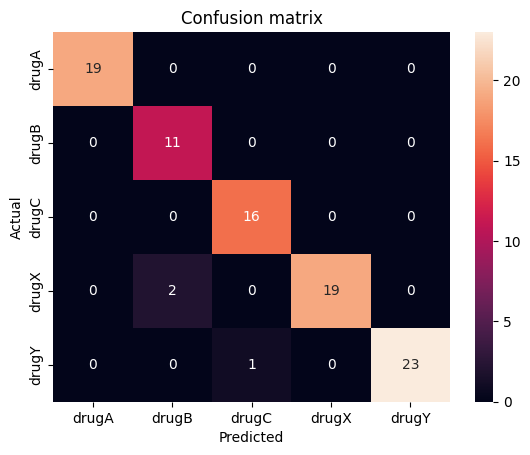

In [11]:
# model training
best_model = grid.best_estimator_

y_Pred = best_model.predict(x_test)

print('✅ accuracy score :',accuracy_score(y_test, y_Pred))
print()
print(classification_report(y_test, y_Pred))
print()
sns.heatmap(confusion_matrix(y_test, y_Pred), annot = True, xticklabels=class_en.classes_, yticklabels=class_en.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()


In [ ]:
# Actual vs Predicted analysis
results = pd.DataFrame({
    'Actual': class_en.inverse_transform(y_test),
    'Predicted': class_en.inverse_transform(y_Pred)
})

results['Correct'] = results['Actual'] == results['Predicted']

results.sample(25)

,Actual,Predicted,Correct
32,drugY,drugY,True
16,drugC,drugC,True
8,drugY,drugY,True
78,drugB,drugB,True
66,drugA,drugA,True
54,drugB,drugB,True
24,drugA,drugA,True
37,drugY,drugY,True
7,drugC,drugC,True
80,drugB,drugB,True


In [46]:
# Degree of confidence
y_prob = best_model.predict_proba(x_test)
confidence = np.max(y_prob, axis=1)

print('Average confidence(in %):',
      confidence.mean()* 100)

Average confidence(in %): 79.76935506920336


In [50]:
# User Prediction

age = int(input('AGE: '))
gender = input('GENDER [F/M]: ').upper()
bp = input('Blood Pressure [HIGH/LOW/NORMAL]: ').upper()
chol = input('Cholestrol [HIGH/NORMAL]: ').upper()
na_to_k = float(input('Na_to_K: '))


# Encoding categorical values
gender_encoded = gender_en.transform([gender])[0]
bp_encoded = bp_en.transform([bp])[0]
chol_encoded = chol_en.transform([chol])[0]


# Create user input
user_ip = np.array([
    [age, gender_encoded, bp_encoded, chol_encoded, na_to_k]
])


# Prediction probabilities
probabilities = best_model.predict_proba(user_ip)[0]

print('\nClass Probabilities:')

for drug, probability in zip(class_en.classes_, probabilities):
    print(f'{drug}: {probability:.2%}')


# Prediction
prediction = best_model.predict(user_ip)[0]

# Decode predicted class
predicted_drug = class_en.inverse_transform([prediction])[0]

# Confidence
confidence = probabilities.max()


print('\n' + '=' * 40)
print('       PREDICTION RESULT')
print('=' * 40)

print(f'Predicted Drug: {predicted_drug}')
print(f'Model Confidence: {confidence:.2%}')

print('=' * 40)


Class Probabilities:
drugA: 0.20%
drugB: 0.00%
drugC: 10.66%
drugX: 87.09%
drugY: 2.05%

       PREDICTION RESULT
Predicted Drug: drugX
Model Confidence: 87.09%


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
